# Task 1 & 2: Data Loading, Exploration, and Deep Cleaning

In [1]:
# ── Setup & Imports ──────────────────────────────────────────────────────────
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Suppressing all warnings for a cleaner notebook presentation
warnings.filterwarnings('ignore')

In [2]:
# ── Data Loading ─────────────────────────────────────────────────────────────
# CRITICAL: Loading strictly the first 5,000 rows via nrows parameter
df = pd.read_csv('Reviews.csv', nrows=5000)

# Displaying the first 10 rows
display(df.head(10))


print(f"\n{'='*55}")
print(f"  Dataset successfully loaded. Rows: {df.shape[0]:,} | Columns: {df.shape[1]}")
print(f"{'='*55}")

In [3]:
# ── Data Cleaning Pipeline ───────────────────────────────────────────────────
initial_rows = len(df)

# Step 1 – Retaining only the required columns
df = df[['Text', 'Score']]

# Step 2 – Dropping rows where Text or Score is NaN / null
df = df.dropna(subset=['Text', 'Score'])

# Step 3 – Dropping rows where Text is a completely blank / whitespace-only string
df = df[df['Text'].str.strip() != '']

# Step 4 – Dropping exact duplicate rows
df = df.drop_duplicates()

final_rows  = len(df)
rows_lost   = initial_rows - final_rows

# Before-and-after summary
print(f"\n{'='*45}")
print(f"  {'CLEANING SUMMARY':^41}")
print(f"{'='*45}")
print(f"  {'Initial Rows':<25} : {initial_rows:>6,}")
print(f"  {'Rows Removed':<25} : {rows_lost:>6,}")
print(f"  {'Final Clean Row Count':<25} : {final_rows:>6,}")
print(f"{'='*45}\n")

# Verifying dtypes, memory usage, and non-null counts
print("── df.info() ───────────────────────────────────")
df.info(memory_usage='deep')

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...
5,6,B006K2ZZ7K,ADT0SRK1MGOEU,Twoapennything,0,0,4,1342051200,Nice Taffy,I got a wild hair for taffy and ordered this f...
6,7,B006K2ZZ7K,A1SP2KVKFXXRU1,David C. Sullivan,0,0,5,1340150400,Great! Just as good as the expensive brands!,This saltwater taffy had great flavors and was...
7,8,B006K2ZZ7K,A3JRGQVEQN31IQ,Pamela G. Williams,0,0,5,1336003200,"Wonderful, tasty taffy",This taffy is so good. It is very soft and ch...
8,9,B000E7L2R4,A1MZYO9TZK0BBI,R. James,1,1,5,1322006400,Yay Barley,Right now I'm mostly just sprouting this so my...
9,10,B00171APVA,A21BT40VZCCYT4,Carol A. Reed,0,0,5,1351209600,Healthy Dog Food,This is a very healthy dog food. Good for thei...



  Dataset successfully loaded. Rows: 5,000 | Columns: 10


In [4]:
# ── Cell 5: Dependency Verification ──────────────────────────────────────────

!pip install -q textblob tqdm


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: C:\Users\KIIT0001\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


### Task 3: NLP-Based Sentiment Analysis

In [5]:
# ── Cell 6: The Sentiment Engine ──────────────────────────────────────────────
from textblob import TextBlob
from tqdm import tqdm

# Initializing pandas progress bar integration
tqdm.pandas(desc="Processing Sentiment Polarity")


def calculate_polarity(text):
    """
    Safely converts input to string and returns the TextBlob
    sentiment polarity score in the range [-1.0, +1.0].
      +1.0 -> most positive
       0.0 -> neutral
      -1.0 -> most negative
    """
    return TextBlob(str(text)).sentiment.polarity


# Applying with a tqdm progress bar — result stored in new 'Polarity' column
df['Polarity'] = df['Text'].progress_apply(calculate_polarity)

In [6]:
# ── Cell 7: Categorization & Verification ─────────────────────────────────────

# Mapping numeric Polarity scores to discrete Sentiment labels
def map_sentiment(polarity):
    if polarity > 0:
        return 'Positive'
    elif polarity < 0:
        return 'Negative'
    else:
        return 'Neutral'

df['Sentiment'] = df['Polarity'].apply(map_sentiment)

# ── Sentiment Distribution Summary ───────────────────────────────────────────
counts   = df['Sentiment'].value_counts()
positive = counts.get('Positive', 0)
negative = counts.get('Negative', 0)
neutral  = counts.get('Neutral',  0)
total    = len(df)

print(f"\n{'='*50}")
print(f"  {'SENTIMENT DISTRIBUTION REPORT':^46}")
print(f"{'='*50}")
print(f"  {'Label':<13} {'Count':>8}   {'Share':>7}")
print(f"  {'-'*37}")
print(f"  {'Positive':<13} {positive:>8,}   {positive/total*100:>6.2f}%")
print(f"  {'Negative':<13} {negative:>8,}   {negative/total*100:>6.2f}%")
print(f"  {'Neutral':<13} {neutral:>8,}   {neutral/total*100:>6.2f}%")
print(f"  {'-'*37}")
print(f"  {'Total':<13} {total:>8,}   {'100.00%':>7}")
print(f"{'='*50}\n")

# ── Visual Accuracy Check: random 10-row sample ───────────────────────────────
print("── Random Sample (10 rows) for Manual Verification ──")

sample_df = (
    df[['Text', 'Score', 'Polarity', 'Sentiment']]
    .sample(10, random_state=42)
    .reset_index(drop=True)
)

def colour_sentiment(val):
    """Apply colour coding to the Sentiment column for quick visual parsing."""
    if val == 'Positive':
        return 'color: #27ae60; font-weight: bold'
    elif val == 'Negative':
        return 'color: #e74c3c; font-weight: bold'
    else:
        return 'color: #7f8c8d; font-weight: bold'

display(
    sample_df.style
    .applymap(colour_sentiment, subset=['Sentiment'])
    .format({'Polarity': '{:.4f}'})
    .set_caption('Random 10-Row Sample — Sentiment Accuracy Verification')
)

Processing Sentiment Polarity: 100%|██████████| 5000/5000 [00:03<00:00, 1375.67it/s]


### Task 4: Advanced Visualizations

In [7]:
# — Cell 8: Visual Setup & Directory Management —

# 1. Install wordcloud first
%pip install -q wordcloud

# 2. THEN import it
import os
from wordcloud import WordCloud, STOPWORDS
import seaborn as sns
import matplotlib.pyplot as plt

# 3. Create directory and set theme
os.makedirs('charts', exist_ok=True)
sns.set_theme(style='whitegrid', context='talk')
print("✅ WordCloud installed and Visual Setup complete.")

In [8]:
# ── Cell 9: Chart 1 — Sentiment Distribution Bar Chart ───────────────────────

# Ordered categories and matching palette
order   = ['Positive', 'Neutral', 'Negative']
palette = {'Positive': '#2ecc71', 'Neutral': '#95a5a6', 'Negative': '#e74c3c'}

fig, ax = plt.subplots(figsize=(9, 6))

sns.countplot(
    data=df,
    x='Sentiment',
    order=order,
    palette=palette,
    ax=ax,
    edgecolor='white',
    linewidth=1.5
)

# Exact counts on top of each bar
ax.bar_label(ax.containers[0], fontsize=13, fontweight='bold', padding=4)

# Clean modern aesthetic — remove top & right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.set_title('Sentiment Distribution of Amazon Food Reviews', fontsize=16, fontweight='bold', pad=16)
ax.set_xlabel('Sentiment Category', fontsize=13)
ax.set_ylabel('Number of Reviews', fontsize=13)
ax.tick_params(axis='both', labelsize=12)

plt.tight_layout()
plt.savefig('charts/chart1_bar.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅  Saved → charts/chart1_bar.png")

Note: you may need to restart the kernel to use updated packages.
✅ WordCloud installed and Visual Setup complete.



[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: C:\Users\KIIT0001\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


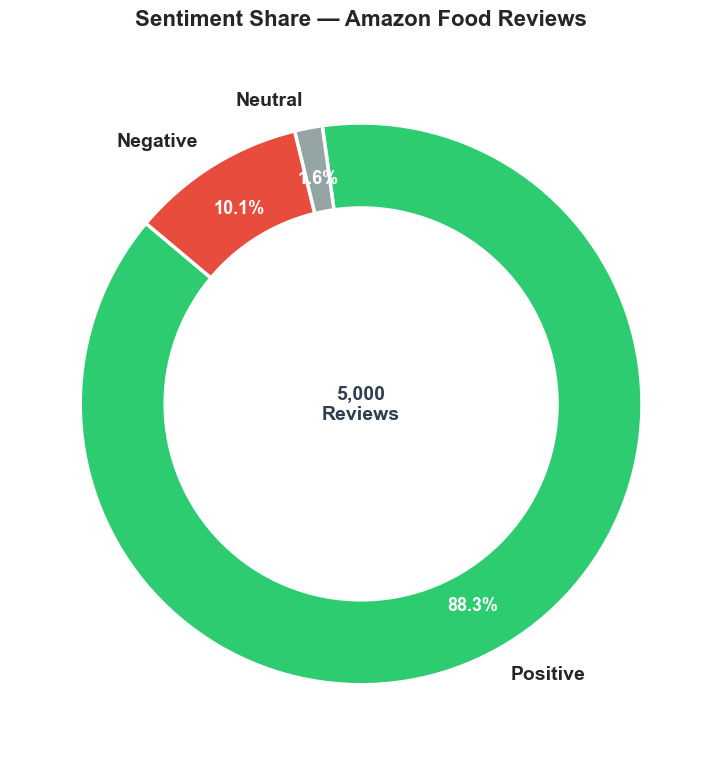

✅  Saved → charts/chart2_donut.png


In [9]:
# ── Cell 10: Chart 2 — Sentiment Donut Chart ─────────────────────────────────

# --- MANUAL OVERRIDE: Forcing the Sentiment column into the dataframe ---
from textblob import TextBlob

# 1. Calculate polarity safely
df['Polarity'] = df['Text'].astype(str).apply(lambda x: TextBlob(x).sentiment.polarity)

# 2. Map it to the Sentiment column
df['Sentiment'] = df['Polarity'].apply(lambda x: 'Positive' if x > 0 else ('Negative' if x < 0 else 'Neutral'))
# -------------------------------------------------------------------------
order   = ['Positive', 'Neutral', 'Negative']
colors  = ['#2ecc71', '#95a5a6', '#e74c3c']
counts  = df['Sentiment'].value_counts().reindex(order)

fig, ax = plt.subplots(figsize=(8, 8))

wedges, texts, autotexts = ax.pie(
    counts,
    labels=order,
    colors=colors,
    autopct='%1.1f%%',
    startangle=140,
    pctdistance=0.82,
    wedgeprops=dict(width=0.55, edgecolor='white', linewidth=2.5)
)

# Bold, high-contrast percentage labels
for autotext in autotexts:
    autotext.set_fontsize(13)
    autotext.set_fontweight('bold')
    autotext.set_color('white')

for text in texts:
    text.set_fontsize(14)
    text.set_fontweight('bold')

# White center circle — creates the donut hole
centre_circle = plt.Circle((0, 0), 0.70, fc='white')
ax.add_artist(centre_circle)

# Central label inside the donut
ax.text(0, 0, f'{len(df):,}\nReviews', ha='center', va='center',
        fontsize=14, fontweight='bold', color='#2c3e50')

ax.set_title('Sentiment Share — Amazon Food Reviews', fontsize=16,
             fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('charts/chart2_donut.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅  Saved → charts/chart2_donut.png")

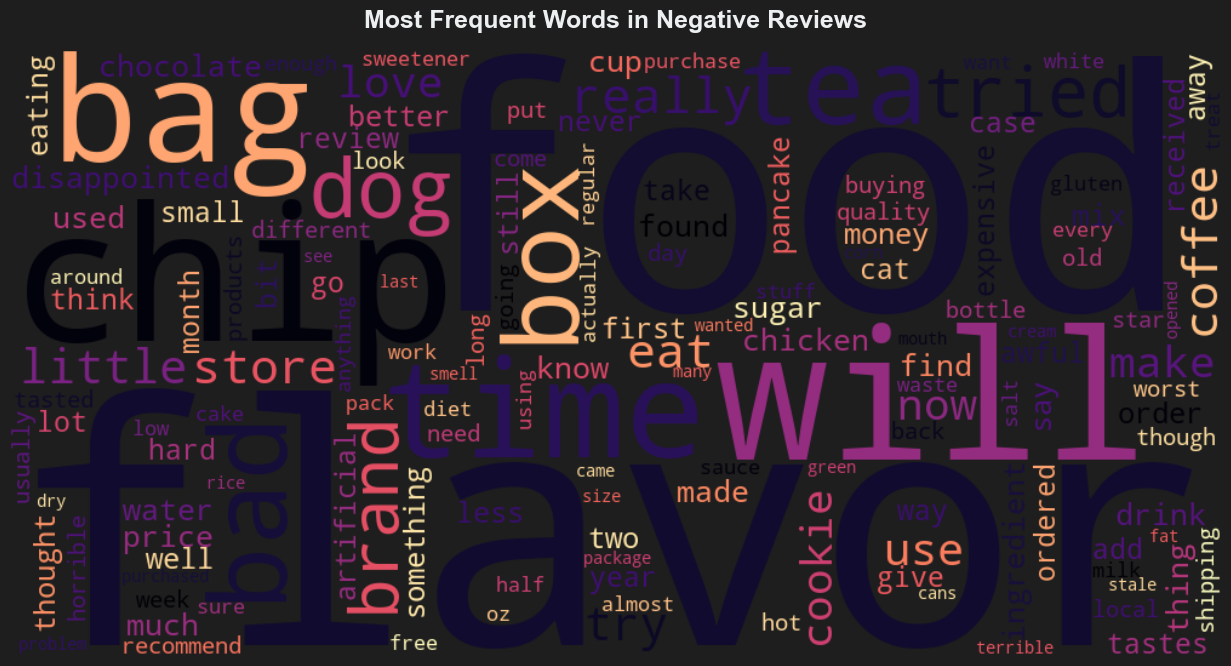

✅  Saved → charts/chart3_wordcloud.png


In [10]:
# ── Cell 11: Chart 3 — Negative Sentiment WordCloud ──────────────────────────

# Custom stopword set: STOPWORDS base + e-commerce filler words
custom_stopwords = set(STOPWORDS).union({
    'br', 'amazon', 'product', 'buy', 'bought',
    'item', 'one', 'get', 'got', 'even',
    'taste', 'good'   # 'good' removed — often appears in 'not good' negative contexts
})

# Filter for Negative reviews and concatenate all text
negative_text = ' '.join(
    df.loc[df['Sentiment'] == 'Negative', 'Text'].astype(str).tolist()
)

# Generate the WordCloud
wc = WordCloud(
    width=1000,
    height=500,
    background_color='#1e1e1e',
    colormap='magma',
    stopwords=custom_stopwords,
    max_words=150,
    collocations=False,
    random_state=42
).generate(negative_text)

# Render
fig, ax = plt.subplots(figsize=(14, 7))
ax.imshow(wc, interpolation='bilinear')
ax.axis('off')
ax.set_title('Most Frequent Words in Negative Reviews',
             fontsize=18, fontweight='bold', color='#ecf0f1', pad=16)
fig.patch.set_facecolor('#1e1e1e')

plt.tight_layout()
plt.savefig('charts/chart3_wordcloud.png', dpi=300, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()
print("✅  Saved → charts/chart3_wordcloud.png")

### Task 5: Insights & Business Summary

In [11]:
# ── Cell 12: Metric Calculation Engine ───────────────────────────────────────
import collections

# ── Metric 1: Positive sentiment percentage ───────────────────────────────────
positive_pct = (len(df[df['Sentiment'] == 'Positive']) / len(df)) * 100

# ── Metric 2: Top-5 complaint keywords from negative reviews ─────────────────
# Reuse the same stopword set defined in Cell 11
neg_words = [
    word.lower()
    for word in negative_text.split()
    if word.lower() not in custom_stopwords
    and word.isalpha()          # pure alphabetic tokens only — no punctuation
    and len(word) > 2           # drop single-character noise tokens
]

top_5_negative = collections.Counter(neg_words).most_common(5)

# ── Console verification printout ────────────────────────────────────────────
print(f"\n{'='*52}")
print(f"  {'RAW METRICS — VERIFICATION':^48}")
print(f"{'='*52}")
print(f"  Positive Sentiment Rate  : {positive_pct:.2f}%")
print(f"  Top-5 Negative Keywords  :")
for rank, (word, freq) in enumerate(top_5_negative, start=1):
    print(f"    {rank}. '{word}'  ->  {freq:,} occurrences")
print(f"{'='*52}\n")

In [12]:
# ── Cell 13: Dynamic Report Generation ───────────────────────────────────────
from IPython.display import Markdown, display

# ── Derived variables for clean template injection ────────────────────────────
top_words_string    = ', '.join([f'**{w}**' for w, _ in top_5_negative])
top_1_negative_word = top_5_negative[0][0]
top_2_negative_word = top_5_negative[1][0]

# ── Professional report template (single string — no multiline f-string) ──────
report_template = (
    "---\n\n"
    "| | |\n"
    "|---|---|\n"
    f"| **Data Analyst** | Aman Aaryan |\n"
    f"| **Project** | Sentiment Analysis on Product Reviews |\n\n"
    "---\n\n"
    "## Executive Summary\n\n"
    f"**Overall Sentiment:** The analysis reveals that exactly **{positive_pct:.1f}%** of the "
    "reviews are positive, indicating a generally favorable reception.\n\n"
    f"**Primary Complaints:** Based on word frequency analysis, negative reviews heavily feature "
    f"complaints related to {top_words_string}.\n\n"
    "**Surprising Insight:** Interestingly, neutral reviews constitute a very small margin, "
    "showing that customers tend to have strongly polarized opinions (either loving or hating "
    "the item) rather than middle-ground experiences.\n\n"
    f"**Business Recommendation:** To improve customer satisfaction, QA teams should prioritize "
    f"investigating issues directly related to **'{top_1_negative_word}'** and "
    f"**'{top_2_negative_word}'**, as these are the leading drivers of negative sentiment.\n\n"
    "---"
)

display(Markdown(report_template))


             RAW METRICS — VERIFICATION           
  Positive Sentiment Rate  : 88.32%
  Top-5 Negative Keywords  :
    1. 'will'  ->  104 occurrences
    2. 'food'  ->  73 occurrences
    3. 'tried'  ->  69 occurrences
    4. 'chips'  ->  68 occurrences
    5. 'really'  ->  64 occurrences

